# ==========================================
# STEP 1: IMPORT LIBRARIES
# Fashion MNIST CNN Classifier
# ==========================================

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# ==========================================
# STEP 2: CONFIGURE DEVICE
# ==========================================

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3070 Laptop GPU


# ==========================================
# STEP 3: LOAD THE FASHION-MNIST DATASET
# ==========================================

In [5]:
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=test_transform
)


# ==========================================
# STEP 4: EXPLORE THE DATASET
# ==========================================

In [6]:
print("Training images :", len(train_dataset))
print("Testing images  :", len(test_dataset))

image, label = train_dataset[0]

print("\nImage shape :", image.shape)
print("Data type   :", image.dtype)
print("Label       :", label)

Training images : 60000
Testing images  : 10000

Image shape : torch.Size([1, 28, 28])
Data type   : torch.float32
Label       : 9


## Fashion-MNIST class names

In [7]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print(class_names)
print("First image class:", class_names[label])

['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']
First image class: Ankle Boot


# ==========================================
# STEP 5: CREATE DATALOADERS
# ==========================================

In [8]:
from torch.utils.data import DataLoader, random_split

# Split training dataset (90% train, 10% validation)
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Check one batch

In [9]:


images, labels = next(iter(train_loader))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)

Image batch shape : torch.Size([64, 1, 28, 28])
Label batch shape : torch.Size([64])


# ==========================================
# STEP 6: VISUALIZE SAMPLE IMAGES
# ==========================================

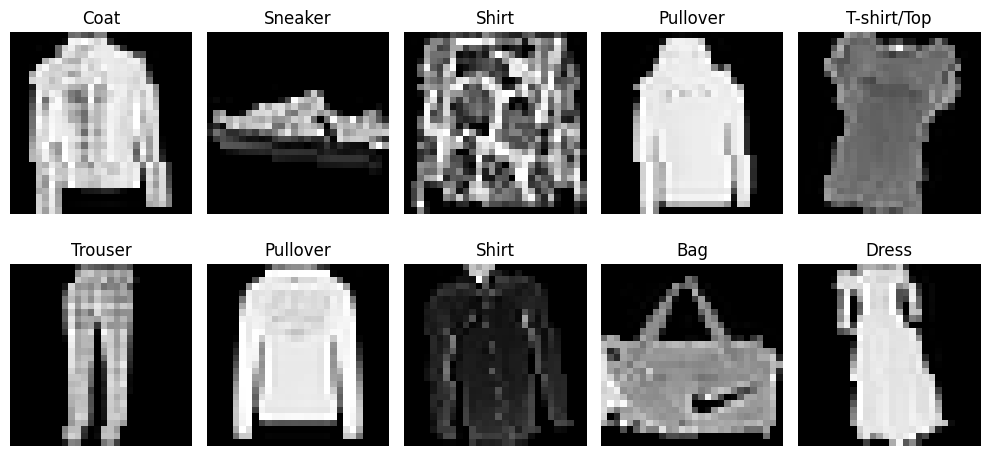

In [10]:

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# ==========================================
# STEP 7: BUILD THE CNN MODEL
# ==========================================

In [11]:
class FashionCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = FashionCNN().to(device)

# ==========================================
# STEP 8: LOSS FUNCTION & OPTIMIZER
# ==========================================

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ==========================================
# STEP 9: TRAIN THE CNN
# ==========================================

In [13]:
import os
os.makedirs("models", exist_ok=True)

# Early Stopping Configuration
best_val_loss = float("inf")
patience = 3
counter = 0

EPOCHS = 20

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # ==========================
    # Training
    # ==========================
    model.train()
    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    # Average Training Loss
    train_loss = train_loss / len(train_loader)

    # ==========================
    # Validation
    # ==========================
    model.eval()
    val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

    # Average Validation Loss
    val_loss = val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # ==========================
    # Early Stopping
    # ==========================
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), "models/fashion_cnn_best.pth")

    else:
        counter += 1

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    if counter >= patience:
        print("\nEarly Stopping Triggered!")
        break

print("\nBest model saved as: models/fashion_cnn_best.pth")

Epoch 01/20 | Train Loss: 0.6099 | Val Loss: 0.4170
Epoch 02/20 | Train Loss: 0.4487 | Val Loss: 0.3483
Epoch 03/20 | Train Loss: 0.4053 | Val Loss: 0.3131
Epoch 04/20 | Train Loss: 0.3817 | Val Loss: 0.3044
Epoch 05/20 | Train Loss: 0.3573 | Val Loss: 0.2896
Epoch 06/20 | Train Loss: 0.3491 | Val Loss: 0.2812
Epoch 07/20 | Train Loss: 0.3311 | Val Loss: 0.2719
Epoch 08/20 | Train Loss: 0.3244 | Val Loss: 0.2711
Epoch 09/20 | Train Loss: 0.3116 | Val Loss: 0.2597
Epoch 10/20 | Train Loss: 0.3047 | Val Loss: 0.2606
Epoch 11/20 | Train Loss: 0.3014 | Val Loss: 0.2600
Epoch 12/20 | Train Loss: 0.2952 | Val Loss: 0.2608

Early Stopping Triggered!

Best model saved as: models/fashion_cnn_best.pth


### LEARNING CURVES

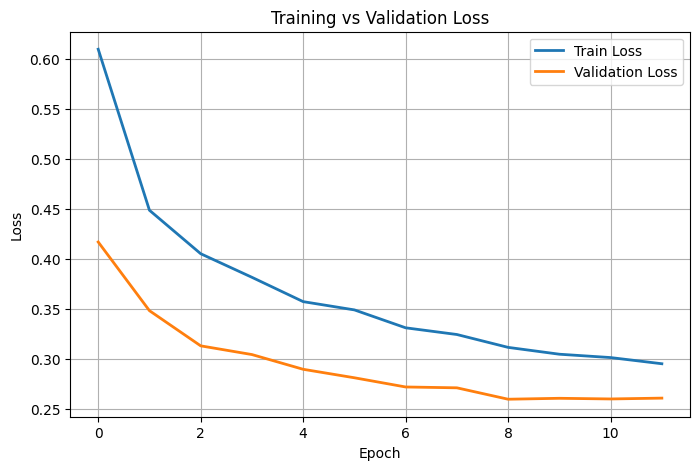

In [14]:

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# ==========================================
# STEP 10: EVALUATE THE MODEL
# ==========================================

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Load best model
model.load_state_dict(torch.load("models/fashion_cnn_best.pth"))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

C:\Users\hp\AppData\Local\Temp\ipykernel_33344\3754691818.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/fashion_cnn_best.pth"

Accuracy : 0.9008
Precision: 0.9011
Recall   : 0.9008
F1 Score : 0.9006


## CLASSIFICATION REPORT

In [16]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/Top       0.84      0.86      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.82      0.89      0.85      1000
       Dress       0.91      0.90      0.90      1000
        Coat       0.86      0.83      0.85      1000
      Sandal       0.99      0.96      0.97      1000
       Shirt       0.74      0.70      0.72      1000
     Sneaker       0.92      0.98      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle Boot       0.98      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



### CONFUSION MATRIX

<Figure size 1000x800 with 0 Axes>

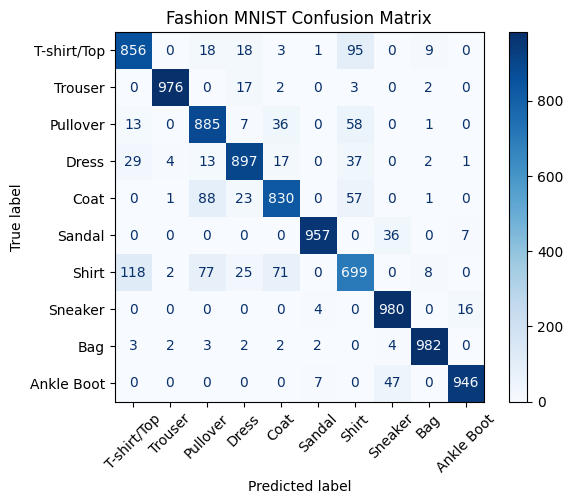

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Fashion MNIST Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# STEP 11: WRONG PREDICTIONS
# ==========================================

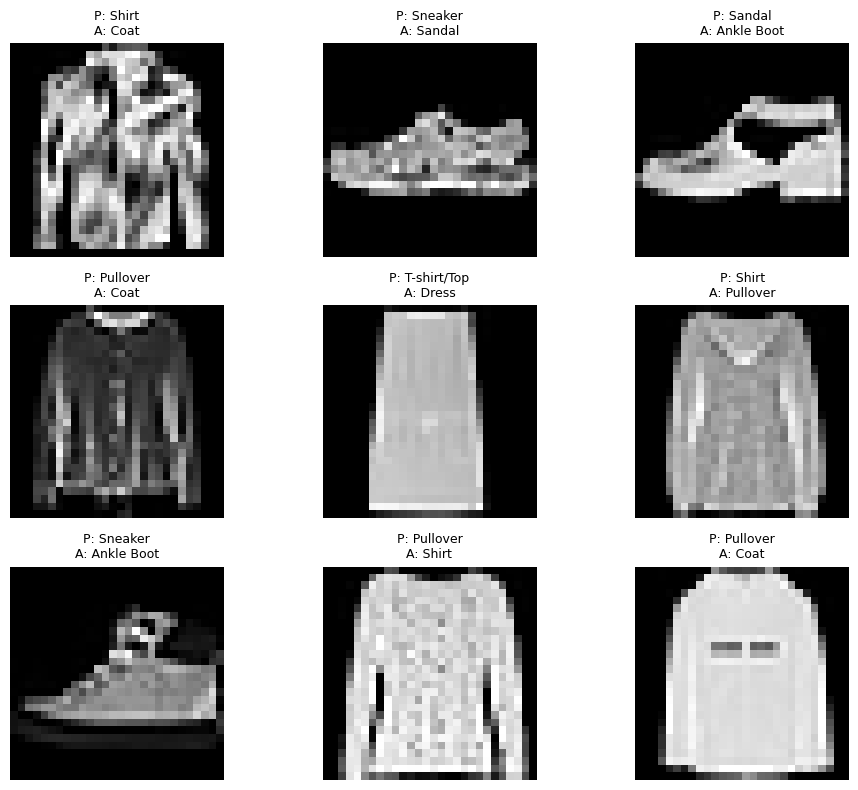

In [18]:
model.eval()

wrong_images = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)

        wrong = preds.cpu() != labels

        wrong_images.extend(images[wrong])
        wrong_preds.extend(preds.cpu()[wrong])
        wrong_labels.extend(labels[wrong])

plt.figure(figsize=(10, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(wrong_images[i].squeeze(), cmap="gray")
    plt.title(
        f"P: {class_names[wrong_preds[i]]}\nA: {class_names[wrong_labels[i]]}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

# ==========================================
# STEP 12: TOP-3 PREDICTIONS
# ==========================================

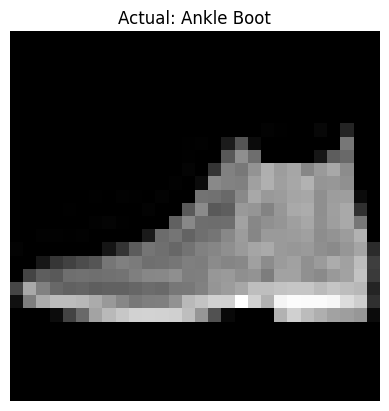

Top 3 Predictions:

1. Ankle Boot - 98.66%
2. Sneaker - 1.32%
3. Sandal - 0.01%


In [19]:
import torch.nn.functional as F

model.eval()

images, labels = next(iter(test_loader))
image = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(image)
    probabilities = F.softmax(outputs, dim=1)

    top_prob, top_class = torch.topk(probabilities, k=3)

plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Actual: {class_names[labels[0]]}")
plt.axis("off")
plt.show()

print("Top 3 Predictions:\n")

for i in range(3):
    print(
        f"{i+1}. {class_names[top_class[0][i]]} "
        f"- {top_prob[0][i]*100:.2f}%"
    )

# ==========================================
# STEP 13: MAKE PREDICTIONS
# ==========================================

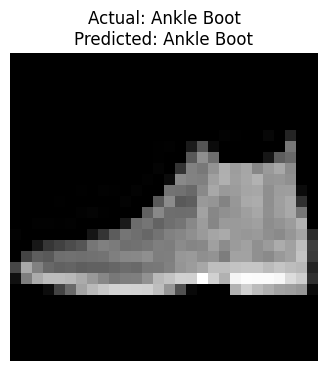

Actual Class     : Ankle Boot
Predicted Class  : Ankle Boot
Confidence       : 98.66%


In [20]:
model.eval()

# Get one image from the test dataset
image, label = test_dataset[0]

# Add batch dimension
image_tensor = image.unsqueeze(0).to(device)

# Prediction
with torch.no_grad():
    output = model(image_tensor)
    probabilities = torch.softmax(output, dim=1)
    confidence, prediction = torch.max(probabilities, dim=1)

# Display image
plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(
    f"Actual: {class_names[label]}\n"
    f"Predicted: {class_names[prediction.item()]}"
)
plt.axis("off")
plt.show()

print(f"Actual Class     : {class_names[label]}")
print(f"Predicted Class  : {class_names[prediction.item()]}")
print(f"Confidence       : {confidence.item() * 100:.2f}%")

# ==========================================
# STEP 14: SAVE DEPLOYMENT MODEL
# ==========================================


In [24]:
from pathlib import Path
import torch

# Project root: Fashion_MNIST_CNN_Classifier
ROOT = Path.cwd().parent

MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / "fashion_cnn_best.pth"

torch.save(model.state_dict(), MODEL_PATH)

print("Saved to:", MODEL_PATH)

Saved to: C:\Users\hp\Videos\AI FULL THEORY AND PROJECTS\AI PROJECTS\DEEP LEARNING PROJECTS\Fashion_MNIST_CNN_Classifier\models\fashion_cnn_best.pth
